Figure 3 in the paper: It illustrates how the QID domain size, $n_Q$, affects the posterior vulnerability as the population size, $n$, increases.

The dashed lines indicate the theoretical limit, defined as the $n_S$-th harmonic number divided by $n_S$.

This Jupyter notebook assumes that ``posterior_vulnerability_att_inf.py`` has already been run with the desired parameter values to generate the required results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

In [2]:
posteriors = pd.read_csv(Path.cwd() / "results/posteriors.csv")
posteriors.head()

,n,na,nq,ns,posterior
0,2,4,2,2,0.928571
1,2,6,2,3,0.900000
2,2,8,2,4,0.884615
3,2,10,2,5,0.875000
4,2,12,2,6,0.868421


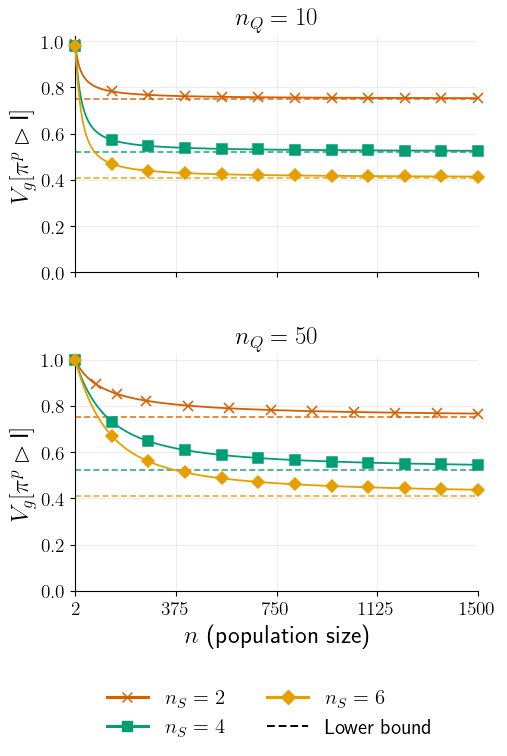

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amssymb}\newcommand{\prior}{\pi}",
})

# Parameters
n_max = 1500
nq_values = [10, 50]
ns_range = [2, 4, 6]

# Asymptotic limits for ns = 2, 3, 4, 5, 6
limit = {
    2: 3/4,
    3: 11/18,
    4: 25/48,
    5: 137/300,
    6: 49/120,
}

# A colorblind-friendly palette
colors = {
    2: "#D55E00",
    3: "#0072B2",
    4: "#009E73",
    5: "#CC79A7",
    6: "#E69F00",
}

markers = {
    2: "x",
    3: "^",
    4: "s",
    5: "o",
    6: "D",
}

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.2,
    "figure.figsize": (5.2, 7.2),
})

fig, axs = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0.35)

for ax, nq in zip(axs, nq_values):
    for ns in ns_range:
        df_sel = posteriors[
            (posteriors["nq"] == nq) &
            (posteriors["ns"] == ns) &
            (posteriors["n"] <= n_max)
        ].copy().sort_values("n")

        X = df_sel["n"].to_numpy()
        Y = df_sel["posterior"].to_numpy()

        marker_idx = np.linspace(0, len(X) - 1, min(12, len(X))).astype(int)

        ax.plot(
            X,
            Y,
            color=colors[ns],
            marker=markers[ns],
            markevery=marker_idx,
            markersize=6.5,
            markeredgewidth=1.1,
            label=rf"$n_S = {ns}$",
            zorder=3,
            linewidth=1.3,
            clip_on=False,
        )

        ax.axhline(
            limit[ns],
            color=colors[ns],
            linestyle=(0, (4, 2)),
            linewidth=1.1,
            alpha=0.9,
            zorder=1,
        )

    ax.set_title(rf"$n_Q = {nq}$", pad=8)
    ax.set_ylabel(r"$V_g[\pi^p \rhd {\sf I}]$")
    ax.set_xlim(2, n_max)
    ax.set_ylim(0, 1.02)

    if n_max <= 20:
        xticks = list(range(2, n_max + 1, max(2, n_max // 4 or 1)))
    else:
        xticks = [2] + list(np.linspace(max(100, n_max // 4), n_max, 4, dtype=int))
        xticks = sorted(set([x for x in xticks if 2 <= x <= n_max]))
    ax.set_xticks(xticks)

    ax.grid(True, which="major", axis="both", alpha=0.22, linewidth=0.8)
    ax.set_axisbelow(True)

axs[-1].set_xlabel(r"$n$ (population size)")

curve_handles = [
    Line2D(
        [0], [0],
        color=colors[ns],
        marker=markers[ns],
        linewidth=2.2,
        markersize=7,
        label=rf"$n_S = {ns}$"
    )
    for ns in ns_range
]

limit_handle = Line2D(
    [0], [0],
    color="black",
    linestyle=(0, (4, 2)),
    linewidth=1.4,
    label="Lower bound"
)

fig.legend(
    handles=curve_handles + [limit_handle],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.12),
)

plt.show()